# 😡🤢😱😊😐😔😲 情绪检测 — EfficientNetB0 迁移学习

**数据集**: FER-2013 Emotion Detection — 48×48 灰度人脸，7 类情绪  
**架构**: EfficientNetB0 (ImageNet 预训练) + 自定义分类头  
**加速**: Mixed Precision FP16 — 适配 NVIDIA P100  
**训练策略**: 两阶段（冻结骨干 → 微调最后 20% 层）

---
## 📑 内容
1. 环境配置与 GPU 检测
2. 超参数定义
3. 数据加载与增强
4. 类别权重（处理不平衡）
5. 样本可视化与分布
6. 模型架构定义
7. 第一阶段训练（冻结骨干）
8. 第二阶段训练（微调）
9. 训练曲线可视化
10. 模型评估（混淆矩阵、分类报告、ROC）
11. 预测结果可视化

# 1. 环境配置与 GPU 检测

In [2]:
# ============================================================
# 基础导入
# ============================================================
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
import tensorflow.keras.layers as L
from   tensorflow.keras.models import Model
from   tensorflow.keras.optimizers import AdamW
from   tensorflow.keras.losses import CategoricalCrossentropy
from   tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback)
from   tensorflow.keras.preprocessing.image import ImageDataGenerator
from   tensorflow.keras import mixed_precision

# ============================================================
# sklearn 评估
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.utils.class_weight import compute_class_weight

print('✅ 所有库导入成功')

✅ 所有库导入成功


In [3]:
# ============================================================
# GPU 检测 & 按需增长内存
# ============================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ 检测到 {len(gpus)} 个 GPU:')
    for gpu in gpus:
        print(f'   ➜ {gpu.name}')
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠️ 未检测到 GPU，将在 CPU 上运行')

# ============================================================
# Mixed Precision (FP16) — P100 约 2x 加速
# ============================================================
mixed_precision.set_global_policy('mixed_float16')
print(f'📐 全局计算精度: {mixed_precision.global_policy().name}')

✅ 检测到 1 个 GPU:
   ➜ /physical_device:GPU:0
📐 全局计算精度: mixed_float16


# 2. 超参数定义

In [14]:
# ============================================================
# 路径
# ============================================================
TRAIN_DIR = "/kaggle/input/datasets/ananthu017/emotion-detection-fer/train"
TEST_DIR  = "/kaggle/input/datasets/ananthu017/emotion-detection-fer/test"

# ============================================================
# 图像 & 训练
# ============================================================
IMG_SIZE    = 48          # 输入尺寸
BATCH_SIZE  = 128         # P100 16GB 可用大 batch
EPOCHS_S1   = 30          # 第一阶段 epoch
EPOCHS_S2   = 30          # 第二阶段 epoch

# ============================================================
# 学习率
# ============================================================
LR_S1_MAX   = 1e-3        # 第一阶段峰值
LR_S2_MAX   = 5e-5        # 第二阶段峰值（微调用低 LR）
WARMUP      = 3           # warmup epoch 数

# ============================================================
# 正则化
# ============================================================
DROPOUT     = 0.4
L2_REG      = 1e-4
LABEL_SMTH  = 0.1         # label smoothing

# ============================================================
# 微调
# ============================================================
FT_PERCENT  = 0.2         # 解冻骨干最后 20% 层
PATIENCE_S1 = 5           # 早停耐心
PATIENCE_S2 = 3

# ============================================================
# 类别
# ============================================================
NUM_CLASSES = 7
CLS = ['Anger','Disgust','Fear','Happy','Neutral','Sadness','Surprise']
EMJ = ['😡','🤢','😱','😊','😐','😔','😲']

# ============================================================
# 随机种子
# ============================================================
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('✅ 超参数定义完成')

✅ 超参数定义完成


# 3. 数据加载与增强

48×48 小图不使用 RandomTranslation（避免丢失关键表情特征）

In [5]:
# ============================================================
# 训练增强（仅训练集）
# ============================================================
train_datagen = ImageDataGenerator(
    rotation_range     = 10,        # 随机旋转 ±10°
    zoom_range         = 0.1,       # 随机缩放 ±10%
    horizontal_flip    = True,      # 水平翻转
    brightness_range   = [0.9, 1.1],# 亮度微调
    validation_split   = 0.2
)

# ============================================================
# 验证/测试（仅归一化）
# ============================================================
test_datagen = ImageDataGenerator()

# ============================================================
# 三个数据流
# ============================================================
train_generator = train_datagen.flow_from_directory(
    directory   = TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    color_mode  = 'grayscale',        # 直接读灰度图
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = SEED
)

val_generator = train_datagen.flow_from_directory(
    directory   = TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    color_mode  = 'grayscale',
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = True,
    seed        = SEED
)

test_generator = test_datagen.flow_from_directory(
    directory   = TEST_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    color_mode  = 'grayscale',
    class_mode  = 'categorical',
    shuffle     = False,              # 测试不打乱
    seed        = SEED
)

print(f'训练: {train_generator.samples} | 验证: {val_generator.samples} | 测试: {test_generator.samples}')

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
训练: 22968 | 验证: 5741 | 测试: 7178


# 4. 类别权重（处理类别不平衡）

少数类样本获得更高 loss 权重，被模型更重视

In [6]:
y_train_labels = train_generator.classes

cw = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
cw_dict = {i: w for i, w in enumerate(cw)}

print('  Emoji  类别      样本数     权重')
print('  ' + '-'*40)
for i, (label, emo) in enumerate(zip(CLS, EMJ)):
    cnt = np.sum(y_train_labels == i)
    print(f'  {emo}  {label:8s}  {cnt:5d}    {cw[i]:.3f}')

  Emoji  类别      样本数     权重
  ----------------------------------------
  😡  Anger      3196    1.027
  🤢  Disgust     349    9.402
  😱  Fear       3278    1.001
  😊  Happy      5772    0.568
  😐  Neutral    3972    0.826
  😔  Sadness    3864    0.849
  😲  Surprise   2537    1.293


# 5. 样本可视化与类别分布

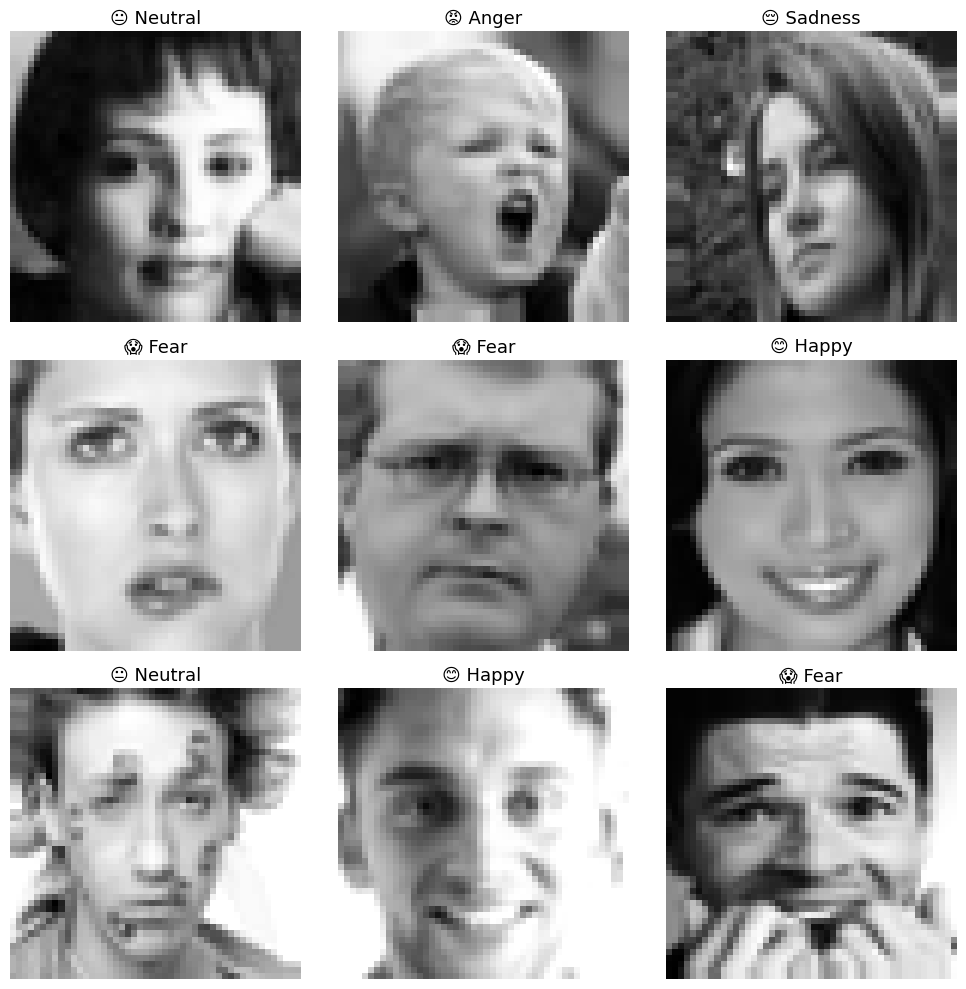

In [7]:
# ============================================================
# 九宫格展示
# ============================================================
imgs, lbls = next(train_generator)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(f'{EMJ[np.argmax(lbls[i])]} {CLS[np.argmax(lbls[i])]}', fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 类别分布柱状图
# ============================================================
cnts = [list(train_generator.classes).count(i) for i in range(NUM_CLASSES)]
fig = px.bar(x=EMJ, y=cnts, color=CLS, labels={'x':'情绪','y':'数量'},
             title='训练集类别分布', color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(showlegend=False)
fig.show()

# 6. 模型架构

```
Input(48,48,1) → Conv2D(3,1×1) → EfficientNetB0(ImageNet) → GAP → Dense(256,Swish) → Dropout(0.4) → Dense(7,Softmax)
```

In [12]:
def build_model():
    """构建 EfficientNetB0 迁移学习模型"""
    inp = L.Input((IMG_SIZE, IMG_SIZE, 1), name='gray_input')
    
    # 灰度→RGB 适配层（1×1 卷积映射为 3 通道）
    x = L.Conv2D(3, (1,1), padding='same', name='adapt_rgb',
    kernel_initializer=tf.keras.initializers.Constant([[[1.0, 1.0, 1.0]]]),
    bias_initializer='zeros')(inp)
    
    # 🔧 2× 上采样：48×48 → 96×96，防止 EfficientNet 过度压缩空间信息
    x = L.UpSampling2D(size=(2, 2), interpolation='bilinear', name='upsample')(x)
    
    # EfficientNetB0（输入变为 96×96）
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE * 2, IMG_SIZE * 2, 3), pooling=None)
    x = base(x, training=False)

    
    # 自定义分类头
    x = L.GlobalAveragePooling2D(name='gap')(x)
    x = L.Dense(256, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='fc1')(x)
    x = L.BatchNormalization(name='bn')(x)
    x = L.Dropout(DROPOUT, name='drop')(x)
    
    # softmax 必须 float32（混合精度下保证数值稳定性）
    out = L.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='out')(x)
    
    return Model(inp, out, name='EmotionNet'), base


model, base_model = build_model()

# 第一阶段：冻结整个骨干
base_model.trainable = False

model.summary()

Model: "EmotionNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gray_input (InputLayer)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adapt_rgb (Conv2D)              │ (None, 48, 48, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ upsample (UpSampling2D)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,336 (16.71 MB)

 Trainable params: 330,253 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [13]:
# ============================================================
# 编译（第一阶段）
# ============================================================
loss_fn = CategoricalCrossentropy(label_smoothing=LABEL_SMTH)

model.compile(
    optimizer=AdamW(learning_rate=LR_S1_MAX, weight_decay=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)
print('✅ 模型编译完成（第一阶段）')

✅ 模型编译完成（第一阶段）


# 7. 第一阶段训练：冻结骨干

只训练灰度适配层 + 分类头，保护 ImageNet 预训练特征不被打乱

In [15]:
# ============================================================
# Warmup + Cosine Decay 自定义 Callback
# ============================================================
class WarmupCosineDecay(Callback):
    def __init__(self, max_lr, warmup_epochs, total_epochs):
        super().__init__()
        self.max_lr   = max_lr
        self.warmup   = warmup_epochs
        self.total    = total_epochs
    
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lr = self.max_lr * (epoch + 1) / self.warmup
        else:
            p = (epoch - self.warmup) / max(1, self.total - self.warmup)
            lr = self.max_lr * 0.5 * (1 + np.cos(np.pi * p))
        self.model.optimizer.learning_rate.assign(lr)
        if epoch == 0:
            print(f'  📉 LR warmup start: {lr:.6f}')


# ============================================================
# 回调
# ============================================================
cbs_s1 = [
    EarlyStopping('val_loss', patience=PATIENCE_S1, restore_best_weights=True, verbose=1),
    WarmupCosineDecay(LR_S1_MAX, WARMUP, EPOCHS_S1),
    ModelCheckpoint('best_s1.keras', monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('🚀 第一阶段训练开始（冻结 EfficientNetB0）')
print(f'   可训参数: 灰度适配层 + 分类头')
print(f'   LR: {LR_S1_MAX} (warmup={WARMUP}ep + cosine decay)')
print('='*60)

h1 = model.fit(
    train_generator,
    epochs         = EPOCHS_S1,
    validation_data = val_generator,
    callbacks      = cbs_s1,
    verbose        = 1
)

print('\n✅ 第一阶段训练完成')

🚀 第一阶段训练开始（冻结 EfficientNetB0）
   可训参数: 灰度适配层 + 分类头
   LR: 0.001 (warmup=3ep + cosine decay)
  📉 LR warmup start: 0.000333
Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 185s 768ms/step - accuracy: 0.2808 - loss: 2.3484 - val_accuracy: 0.4238 - val_loss: 1.7036
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 43s 240ms/step - accuracy: 0.3889 - loss: 1.8834 - val_accuracy: 0.4545 - val_loss: 1.6044
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.4242 - loss: 1.7072 - val_accuracy: 0.4710 - val_loss: 1.5725
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 231ms/step - accuracy: 0.4603 - loss: 1.5926 - val_accuracy: 0.4788 - val_loss: 1.5425
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 41s 229ms/step - accuracy: 0.4782 - loss: 1.5514 - val_accuracy: 0.4905 - val_loss: 1.5348
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.4886 - loss: 1.5289 - val_accuracy: 0.4964 - val_loss: 1.5169
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.4914 - loss: 1.5081 - 

# 8. 第二阶段训练：微调

解冻 EfficientNetB0 最后 20% 层，以极低学习率微调

In [16]:
# ============================================================
# 解冻最后 20% 层
# ============================================================
base_model.trainable = True
total_l = len(base_model.layers)
freeze_until = int(total_l * (1 - FT_PERCENT))

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

print(f'EfficientNetB0 总层数: {total_l}')
print(f'冻结前 {freeze_until} 层, 可训练后 {total_l - freeze_until} 层')

EfficientNetB0 总层数: 238
冻结前 190 层, 可训练后 48 层


In [17]:
# ============================================================
# 重新编译（更低 LR，更低 weight decay）
# ============================================================
model.compile(
    optimizer=AdamW(learning_rate=LR_S2_MAX, weight_decay=5e-4),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMTH * 0.5),
    metrics=['accuracy']
)

# ============================================================
# 回调
# ============================================================
cbs_s2 = [
    EarlyStopping('val_loss', patience=PATIENCE_S2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau('val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_s2.keras', monitor='val_accuracy', save_best_only=True, verbose=0),
]

print('🔧 第二阶段微调开始')
print(f'   LR: {LR_S2_MAX} + ReduceLROnPlateau')
print('='*60)

h2 = model.fit(
    train_generator,
    epochs          = EPOCHS_S2,
    validation_data = val_generator,
    class_weight    = cw_dict,
    callbacks       = cbs_s2,
    verbose         = 1
)

print('\n✅ 第二阶段微调完成')

🔧 第二阶段微调开始
   LR: 5e-05 + ReduceLROnPlateau
Epoch 1/30


2026-05-14 16:20:36.709739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:20:36.902270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:20:37.204269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:20:37.428244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:20:38.656710: E external/local_xla/xla/stream_

123/180 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.3108 - loss: 2.2801

2026-05-14 16:21:31.929226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:21:32.124587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:21:32.415617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:21:32.632865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 16:21:33.809373: E external/local_xla/xla/stream_

180/180 ━━━━━━━━━━━━━━━━━━━━ 143s 514ms/step - accuracy: 0.3217 - loss: 2.2382 - val_accuracy: 0.4405 - val_loss: 1.6235 - learning_rate: 5.0000e-05
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.4167 - loss: 1.7906 - val_accuracy: 0.4337 - val_loss: 1.6331 - learning_rate: 5.0000e-05
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 47s 261ms/step - accuracy: 0.4405 - loss: 1.6609 - val_accuracy: 0.4600 - val_loss: 1.5869 - learning_rate: 5.0000e-05
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 247ms/step - accuracy: 0.4572 - loss: 1.5458 - val_accuracy: 0.4743 - val_loss: 1.5431 - learning_rate: 5.0000e-05
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.4832 - loss: 1.4804 - val_accuracy: 0.4827 - val_loss: 1.5108 - learning_rate: 5.0000e-05
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.4945 - loss: 1.4170 - val_accuracy: 0.4961 - val_loss: 1.4814 - learning_rate: 5.0000e-05
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 244ms/step -

In [18]:
# ============================================================
# 合并两阶段历史
# ============================================================
df1 = pd.DataFrame(h1.history)
df2 = pd.DataFrame(h2.history)
df2.index += len(df1)
hist = pd.concat([df1, df2], ignore_index=False).reset_index(drop=True)

print('📊 训练历史合并完成')

📊 训练历史合并完成


# 9. 训练曲线可视化

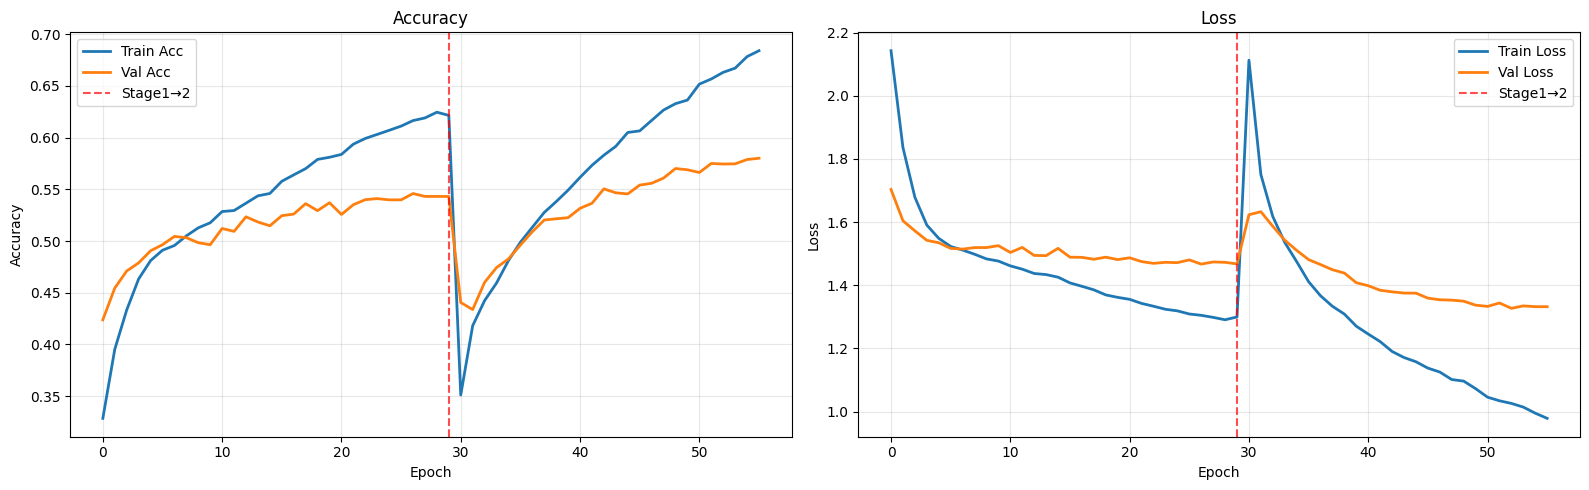

In [20]:
# ============================================================
# 双坐标图：Accuracy + Loss
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 阶段分隔线
sep = len(df1) - 1

ax1.plot(hist['accuracy'],     label='Train Acc', lw=2)
ax1.plot(hist['val_accuracy'], label='Val Acc',   lw=2)
if sep > 0:
    ax1.axvline(sep, color='red', ls='--', alpha=0.7, label='Stage1→2')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist['loss'],     label='Train Loss', lw=2)
ax2.plot(hist['val_loss'], label='Val Loss',   lw=2)
if sep > 0:
    ax2.axvline(sep, color='red', ls='--', alpha=0.7, label='Stage1→2')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [21]:
# ============================================================
# Plotly 交互版本
# ============================================================
fig = px.line(hist, y=['accuracy','val_accuracy'], markers=True,
              title='Accuracy', labels={'index':'Epoch','value':'Accuracy'})
fig.show()

fig = px.line(hist, y=['loss','val_loss'], markers=True,
              title='Loss', labels={'index':'Epoch','value':'Loss'})
fig.show()

# 10. 模型评估

In [22]:
# ============================================================
# 测试集评估
# ============================================================
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\n✅ 测试 Accuracy: {test_acc:.4f}')
print(f'✅ 测试 Loss:     {test_loss:.4f}')

# 预测
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5665 - loss: 1.3685 

✅ 测试 Accuracy: 0.5945
✅ 测试 Loss:     1.2986
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 297ms/step


## 混淆矩阵

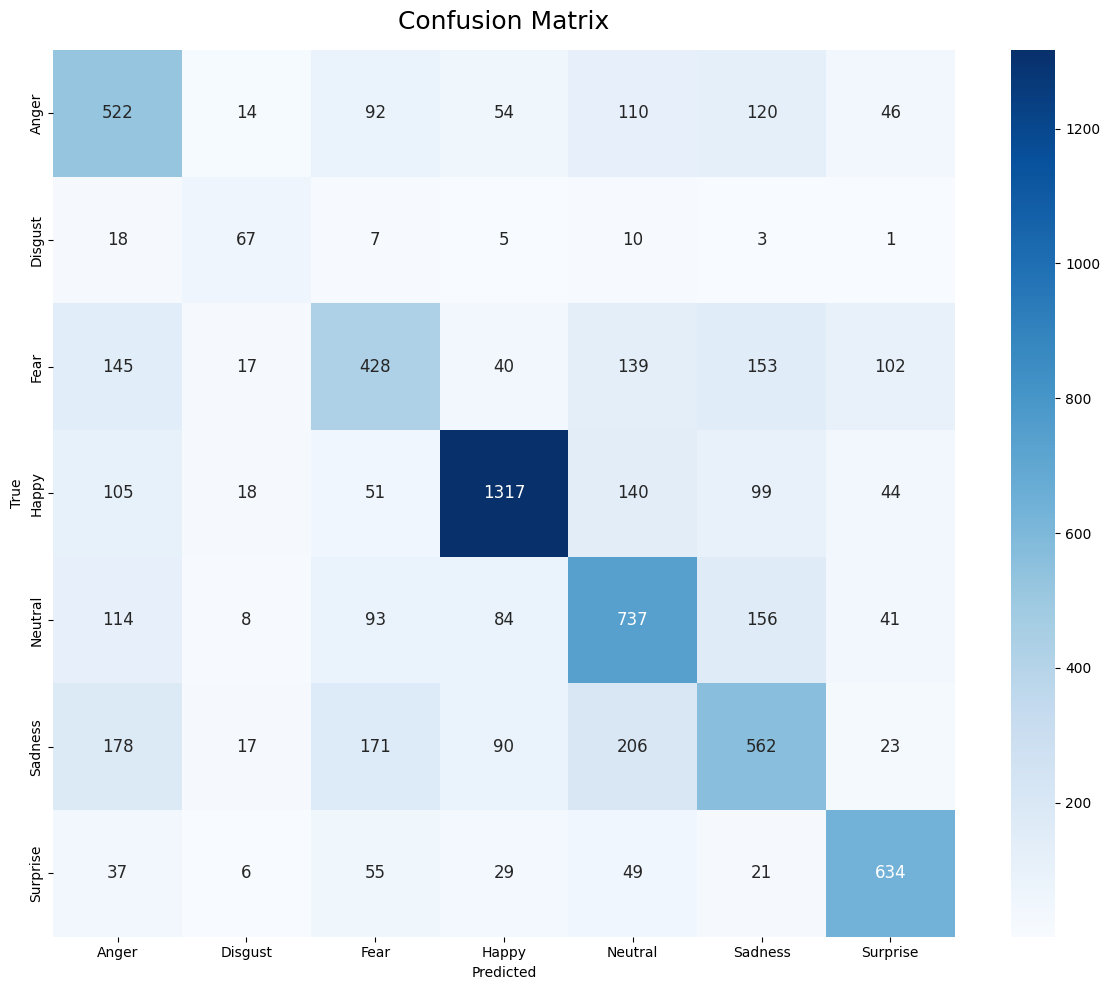

In [23]:
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=CLS, columns=CLS)
cm_df.index.name = 'True'; cm_df.columns.name = 'Predicted'

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', annot_kws={'size':12})
plt.title('Confusion Matrix', fontsize=18, pad=15)
plt.tight_layout(); plt.show()

## 分类报告

In [24]:
print(classification_report(y_true, y_pred, target_names=CLS, digits=4))

              precision    recall  f1-score   support

       Anger     0.4665    0.5449    0.5026       958
     Disgust     0.4558    0.6036    0.5194       111
        Fear     0.4771    0.4180    0.4456      1024
       Happy     0.8135    0.7424    0.7763      1774
     Neutral     0.5298    0.5977    0.5617      1233
     Sadness     0.5045    0.4507    0.4761      1247
    Surprise     0.7116    0.7629    0.7364       831

    accuracy                         0.5945      7178
   macro avg     0.5655    0.5886    0.5740      7178
weighted avg     0.5995    0.5945    0.5950      7178



## ROC 曲线

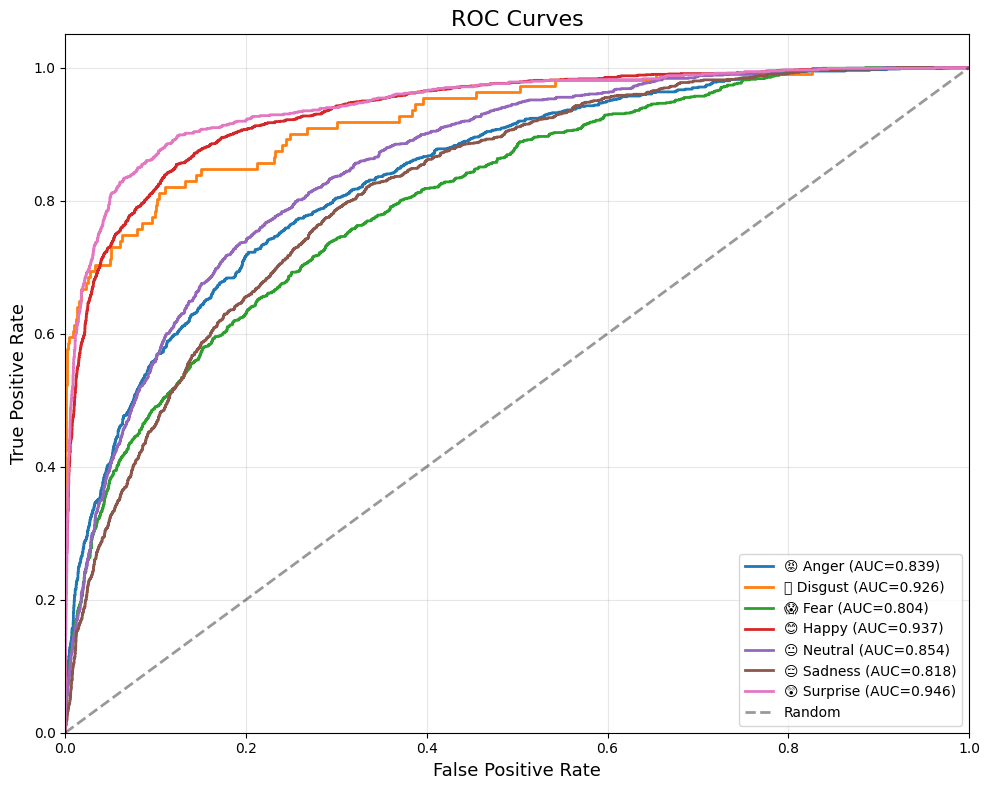

Macro-Avg AUC:    0.8749
Weighted-Avg AUC: 0.8709


In [25]:
lb = LabelBinarizer()
y_true_oh = lb.fit_transform(y_true)

fig, ax = plt.subplots(figsize=(10, 8))
for i, (label, emo) in enumerate(zip(CLS, EMJ)):
    fpr, tpr, _ = roc_curve(y_true_oh[:, i], preds[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'{emo} {label} (AUC={auc(fpr,tpr):.3f})')

ax.plot([0,1],[0,1],'k--',lw=2,alpha=0.4,label='Random')
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves', fontsize=16)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Macro-Avg AUC:    {roc_auc_score(y_true_oh, preds, average="macro"):.4f}')
print(f'Weighted-Avg AUC: {roc_auc_score(y_true_oh, preds, average="weighted"):.4f}')

# 11. 预测结果可视化

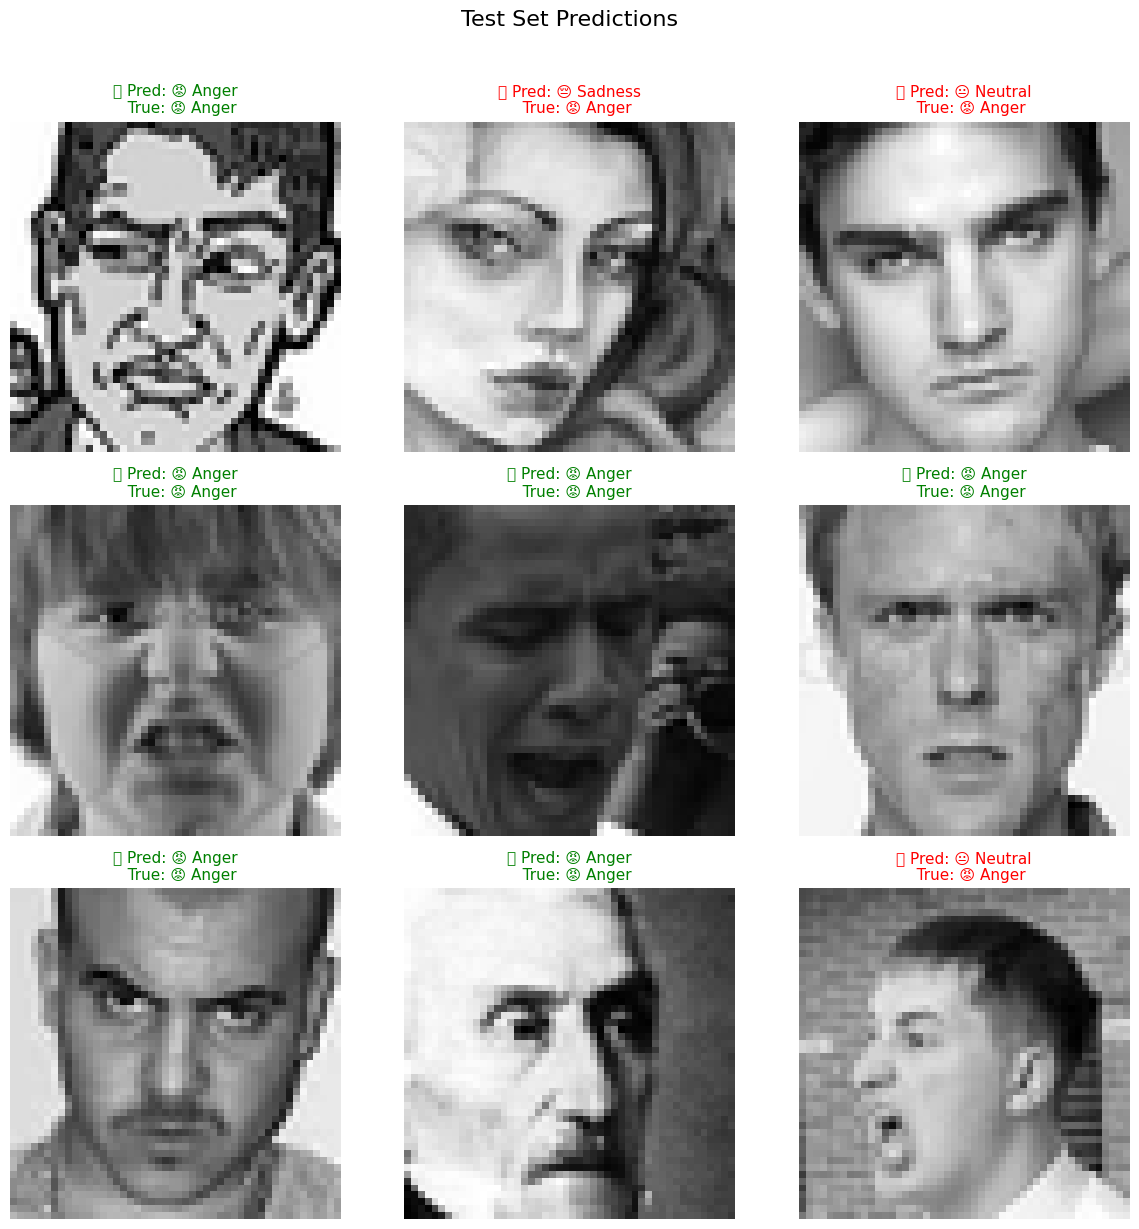

In [26]:
timgs, tlbls = next(test_generator)
tpreds = model.predict(timgs, verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.ravel()):
    img  = timgs[i].squeeze()
    tidx = np.argmax(tlbls[i])
    pidx = np.argmax(tpreds[i])
    ok   = (tidx == pidx)
    c    = 'green' if ok else 'red'
    mark = '✅' if ok else '❌'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{mark} Pred: {EMJ[pidx]} {CLS[pidx]}\n   True: {EMJ[tidx]} {CLS[tidx]}', color=c, fontsize=11)
    ax.axis('off')
plt.suptitle('Test Set Predictions', fontsize=16, y=1.02)
plt.tight_layout(); plt.show()

## 保存模型

In [27]:
model.save('emotion_model_final.keras')
print('✅ 模型已保存: emotion_model_final.keras')

✅ 模型已保存: emotion_model_final.keras


---
# 🎉 训练完成！

| 组件 | 配置 |
|------|------|
| 骨干 | EfficientNetB0 (ImageNet 预训练) |
| 输入 | 48×48 灰度 → 1×1 Conv 适配 RGB |
| 分类头 | GAP → Dense(256,Swish) → Dropout(0.4) → Softmax(7) |
| 优化器 | AdamW + Warmup + Cosine Decay |
| 正则化 | Label Smoothing + L2 + Dropout + 类别权重 |
| 加速 | Mixed Precision FP16 (P100 ~2x) |
| 总参数量 | ~4.5M（极轻量） |

---
*For Kaggle P100 GPU environment*

# 12. 单张图像预测

In [ ]:
# ============================================================
# 单张图像情绪预测
# ============================================================
import cv2

def predict_emotion(image_path, model):
    """
    输入任意人脸图像路径，输出预测情绪
    
    参数:
        image_path: str — 图像文件路径
        model:      keras Model — 训练好的模型
    
    返回:
        dict — {'class', 'confidence', 'all_probs'}
    """
    # 1. 读取图像为灰度
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'无法读取图像: {image_path}')
    
    # 2. 缩放到 48×48
    img = cv2.resize(img, (48, 48))
    
    # 3. 归一化到 [0, 1] 并加 batch + channel 维度
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # shape: (1, 48, 48, 1)
    
    # 4. 预测
    probs = model.predict(img, verbose=0)[0]
    pred_idx = np.argmax(probs)
    confidence = probs[pred_idx]
    
    # 5. 结果
    print(f'🎯 预测: {EMJ[pred_idx]} {CLS[pred_idx]} ({confidence:.1%})')
    print('-' * 40)
    print('所有类别概率:')
    for i, (emo, label) in enumerate(zip(EMJ, CLS)):
        bar = '█' * int(probs[i] * 40)
        print(f'  {emo} {label:8s}  {probs[i]:.4f}  {bar}')
    
    # 6. 显示图像
    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'{EMJ[pred_idx]} {CLS[pred_idx]}', fontsize=14)
    plt.axis('off')
    plt.show()
    
    return {'class': CLS[pred_idx], 'confidence': float(confidence), 'all_probs': probs.tolist()}


# ============================================================
# 使用示例（替换为你的图像路径）
# ============================================================
image_path = '/kaggle/input/your-image.jpg'  # 改成你的图像路径
result = predict_emotion(image_path, model)
